### Ідея:

Модель будує прогноз як суму вкладень кожної фічі:

y = f1(x1) + f2(x2) + f3(x3) + ...

#### Інтуїція

Замість:

> y = complicated function(x1, x2, x3)

ми маємо:

> y = f1(x1) + f2(x2) + f3(x3)

👉 Це дає:

- інтерпретованість
- контроль над переобученням

### Типи моделей:

1. Linear Regression (простий випадок)
2. Generalized Additive Models (GAM)
3. Gradient Boosting (частково additive!)

In [12]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# 1. Load dataset
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# 2. Стандаризація (ВАЖЛИВО для інтерпретації!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train model
model = LinearRegression()
model.fit(X_scaled, y)

# 4. Коефіцієнти
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient",
               ascending=False)

print(coef_df)

      feature  coefficient
0      MedInc     0.829619
3   AveBedrms     0.305696
1    HouseAge     0.118752
4  Population    -0.004503
5    AveOccup    -0.039326
2    AveRooms    -0.265527
7   Longitude    -0.870541
6    Latitude    -0.899886


1. MedInc (median income)

👉 найбільший вплив
→ чим більший дохід → тим дорожче житло

2. Latitude / Longitude

👉 великий негативний коефіцієнт
→ географія сильно впливає

3. Знак коефіцієнта

+ → фіча збільшує prediction

- → зменшує

In [9]:
df = X.copy()
df['target'] = y

In [14]:
corr_matrix = df.corr()

<Axes: >

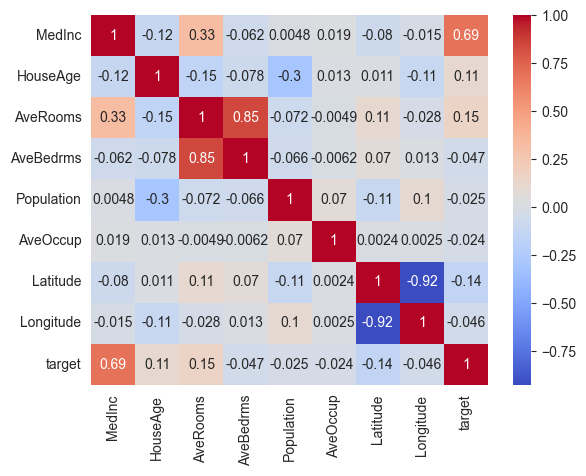

In [15]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

In [17]:
corr_matrix['target'].sort_values(ascending=False)

target        1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: target, dtype: float64

In [20]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.copy()  # features only

vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

# 👉 правило:
# VIF < 5 → ок
# VIF > 10 → проблема

vif

,feature,VIF
7,Longitude,633.711654
6,Latitude,559.874071
2,AveRooms,45.993601
3,AveBedrms,43.590314
0,MedInc,11.511140
1,HouseAge,7.195917
4,Population,2.935745
5,AveOccup,1.095243


 94%|=================== | 4853/5160 [00:11<00:00]       

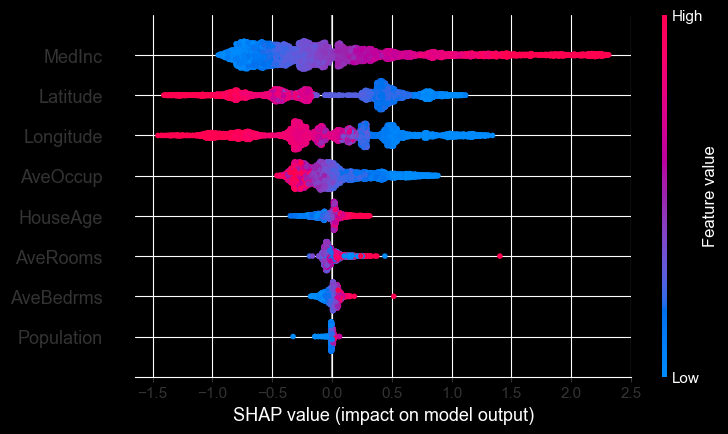

In [9]:
import shap
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# 1. Data
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Model (additive, але складніший за linear)
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# 3. SHAP explainer
background = shap.sample(X_train, 200, random_state=42)
explainer = shap.TreeExplainer(model, data=background)

# 4. SHAP values
shap_exp = explainer(X_test, check_additivity=False)

# 5. Global importance
shap.plots.beeswarm(shap_exp)

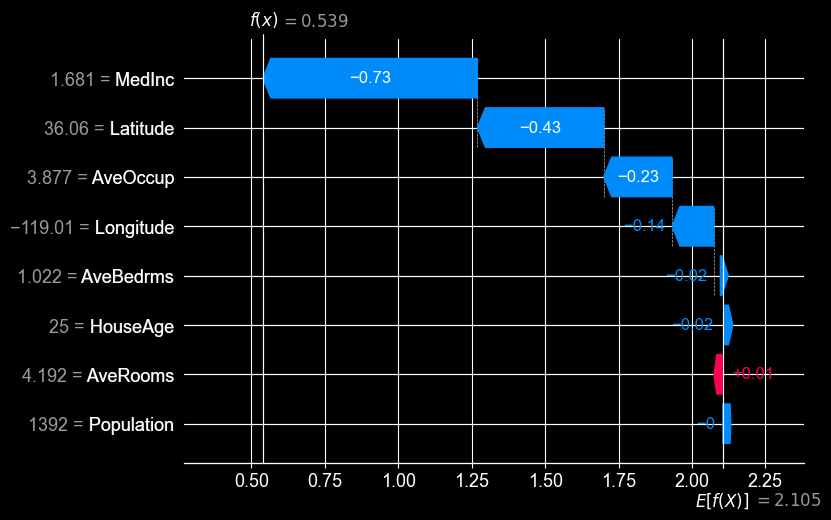

In [8]:
shap.plots.waterfall(shap_exp[0])  # one sample

In [22]:
import pandas as pd

# Базове значення (середній прогноз моделі)
i = 20
base_value = shap_exp.base_values[i]

# SHAP values для цього рядка
contrib = pd.Series(shap_exp.values[i], index=X.columns)

print("Base value:", base_value)
print("\nFeature contributions (SHAP):")
print(contrib.sort_values(ascending=False))

# Перевірка: сума = prediction
prediction = model.predict(X_test.iloc[[i]])[0]
print("\nPrediction:", prediction)
print("Base + sum(SHAP):", base_value + contrib.sum())

Base value: 2.104867922976957

Feature contributions (SHAP):
AveOccup      0.804219
Longitude     0.558405
MedInc        0.219701
HouseAge      0.115739
AveBedrms     0.007471
Population    0.004654
AveRooms     -0.030583
Latitude     -0.206432
dtype: float64

Prediction: 3.578041699600016
Base + sum(SHAP): 3.5780417082192093
